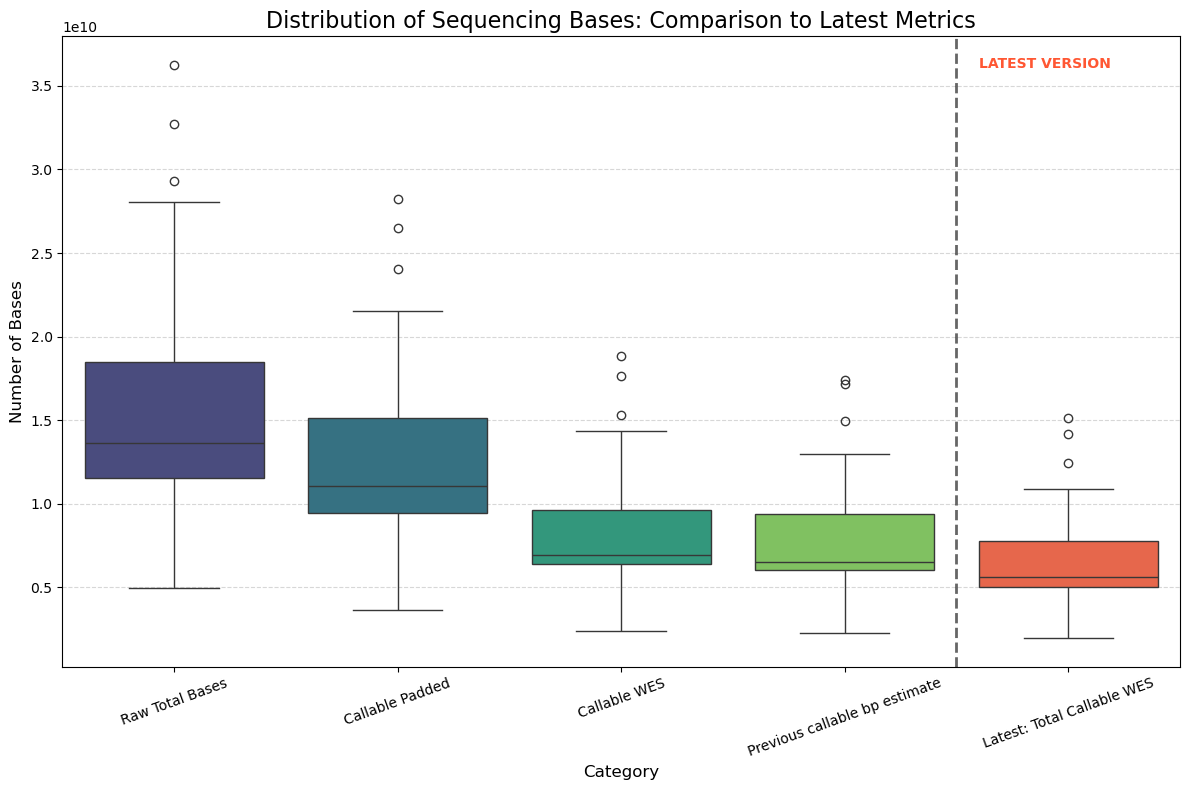

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data 
file1_path = '../denominator_calculations/master_list_old_depth.csv'           # Previous estimates
file2_path = '../denominator_calculations/complete_processed_metadata.csv'     # Metadata
file3_path = 'complete_processed_metadata.csv'             # REPLACE with your third file name

df1 = pd.read_csv(file1_path)
df2 = pd.read_csv(file2_path)
df3 = pd.read_csv(file3_path)

# 2. Merge the files on 'sample_id'
# Chaining merges to include all necessary data
merged_df = pd.merge(df1, df2, on='sample_id', how='inner')
merged_df = pd.merge(merged_df, df3, on='sample_id', how='inner')

# 3. Select columns in the requested order (Latest version on the far right)
columns_to_plot = [
    'raw_total_bases', 
    'callable_sequenced_bases_padded', 
    'callable_sequenced_bases_wes', 
    'bases',
    'total_callable_bases_in_wes'  # New column on the right
]

# Create subset and rename for clean labels
plot_data = merged_df[columns_to_plot].rename(columns={
    'raw_total_bases': 'Raw Total Bases',
    'callable_sequenced_bases_padded': 'Callable Padded',
    'callable_sequenced_bases_wes': 'Callable WES',
    'bases': 'Previous callable bp estimate',
    'total_callable_bases_in_wes': 'Latest: Total Callable WES'
})

# 4. Create the plot
plt.figure(figsize=(12, 8))

# SIGNALING VERSION: Define a custom color palette 
# (Viridis for the old data, a distinct color like "Orange" or "Red" for the latest)
colors = sns.color_palette("viridis", n_colors=len(columns_to_plot)-1) + ["#FF5733"] 

# Create the boxplot
ax = sns.boxplot(data=plot_data, orient='v', palette=colors)

# SIGNALING VERSION: Add a vertical dashed line to separate the latest data
# The x-axis indices are 0, 1, 2, 3, 4. We put the line at 3.5.
plt.axvline(x=3.5, color='black', linestyle='--', linewidth=2, alpha=0.6)

# Optional: Add a text label above the separator
plt.text(3.6, plt.gca().get_ylim()[1] * 0.95, 'LATEST VERSION', 
         color='#FF5733', fontweight='bold', fontsize=10)

# Titles and labels
plt.title('Distribution of Sequencing Bases: Comparison to Latest Metrics', fontsize=16)
plt.ylabel('Number of Bases', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Uncomment if the Raw Bases scale is too large compared to the others
# plt.yscale('log')

plt.tight_layout()
plt.show()

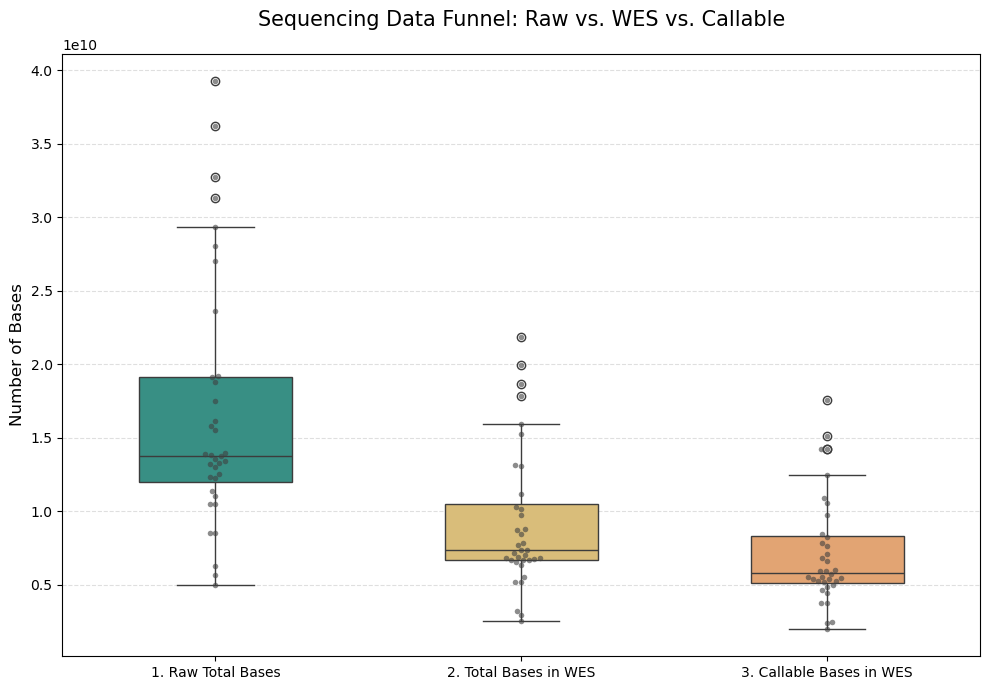

Analysis complete for 36 samples.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the specific files
file1_path = '../denominator_calculations/complete_processed_metadata.csv'
file3_path = 'complete_processed_metadata.csv'

df1 = pd.read_csv(file1_path)
df3 = pd.read_csv(file3_path)

# 2. Merge on sample_id
# We only need 'raw_total_bases' from df1 and the two WES columns from df3
merged_df = pd.merge(
    df1[['sample_id', 'raw_total_bases']], 
    df3[['sample_id', 'total_bases_in_wes', 'total_callable_bases_in_wes']], 
    on='sample_id', 
    how='inner'
)

# 3. Prepare data for plotting
# Order: Raw -> WES Total -> WES Callable
columns_to_plot = [
    'raw_total_bases', 
    'total_bases_in_wes', 
    'total_callable_bases_in_wes'
]

plot_data = merged_df[columns_to_plot].rename(columns={
    'raw_total_bases': '1. Raw Total Bases',
    'total_bases_in_wes': '2. Total Bases in WES',
    'total_callable_bases_in_wes': '3. Callable Bases in WES'
})

# 4. Create the Plot
plt.figure(figsize=(10, 7))

# Using a sequential palette to show the "funnel" effect
colors = ["#2a9d8f", "#e9c46a", "#f4a261"]

# Plotting with a swarmplot overlay to see the 36 individual samples
ax = sns.boxplot(data=plot_data, palette=colors, width=0.5)
sns.swarmplot(data=plot_data, color=".25", size=4, alpha=0.6)

# Titles and Formatting
plt.title('Sequencing Data Funnel: Raw vs. WES vs. Callable', fontsize=15, pad=20)
plt.ylabel('Number of Bases', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Log Scale Option: 
# If 'Raw Total Bases' is 10x larger than WES bases, the WES boxes might look 
# squashed. If so, uncomment the line below:
# plt.yscale('log')

plt.tight_layout()
plt.show()

# Quick sanity check printout
print(f"Analysis complete for {len(merged_df)} samples.")

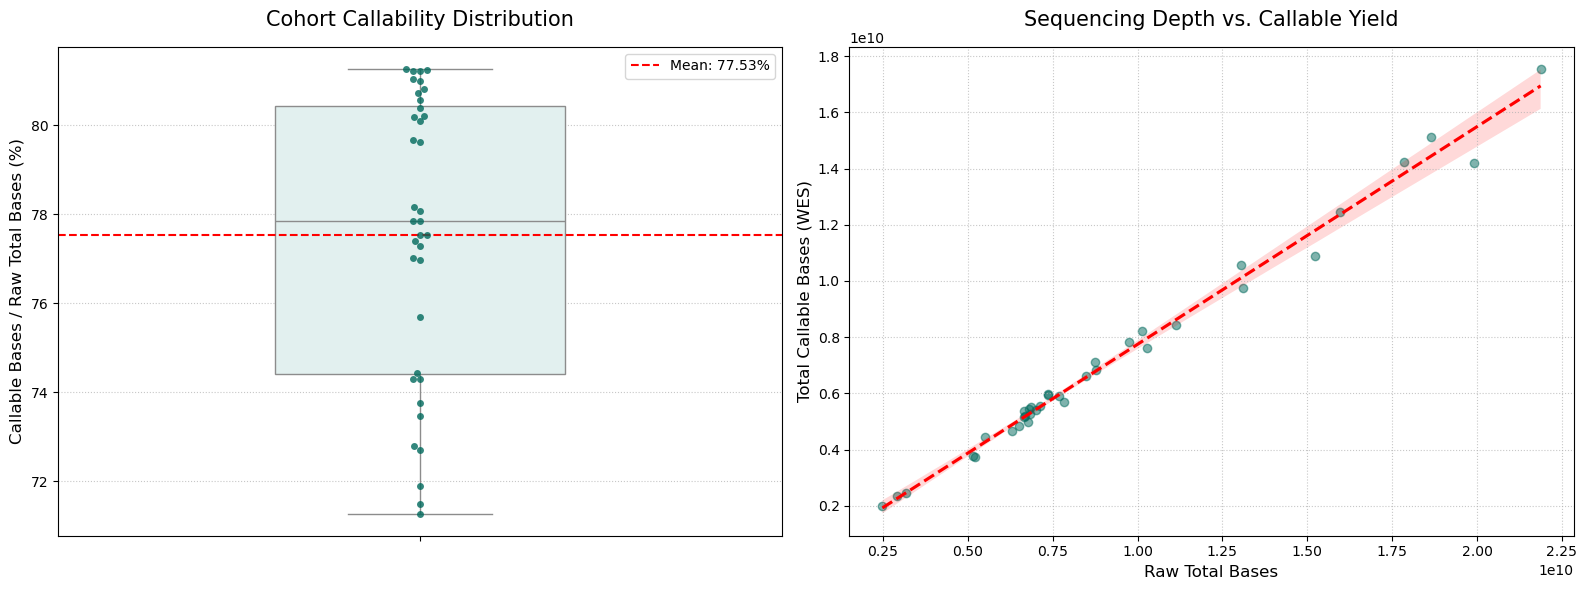

------------------------------
COHORT CALLABILITY SUMMARY
------------------------------
Number of Samples:  36
Mean Callability:   77.53%
Median Callability: 77.85%
Standard Deviation: 3.23%
Min / Max:          71.28% / 81.26%
------------------------------


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
file_path = 'complete_processed_metadata.csv'
df = pd.read_csv(file_path)

# 2. Calculate the Percentage Metric
# This gives the "yield" of callable bases from the raw sequencing data
df['callability_pct'] = (df['total_callable_bases_in_wes'] / df['total_bases_in_wes']) * 100

# 3. Setup the visualization (Two panels for a complete cohort overview)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left Panel: Cohort Distribution (Precision & Consistency) ---
# We use a boxplot to see the median/quartiles and a swarmplot to see every individual sample
sns.boxplot(y='callability_pct', data=df, ax=ax1, color='#e0f2f1', width=0.4)
sns.swarmplot(y='callability_pct', data=df, ax=ax1, color='#00695c', alpha=0.8)

# Add a horizontal line for the cohort average
cohort_avg = df['callability_pct'].mean()
ax1.axhline(cohort_avg, color='red', linestyle='--', label=f'Mean: {cohort_avg:.2f}%')

ax1.set_title('Cohort Callability Distribution', fontsize=15, pad=15)
ax1.set_ylabel('Callable Bases / Raw Total Bases (%)', fontsize=12)
ax1.grid(axis='y', linestyle=':', alpha=0.7)
ax1.legend()

# --- Right Panel: Scaling & Efficiency (Scatter with Regression) ---
# This shows if you get a consistent "return" on more sequencing depth
sns.regplot(x='total_bases_in_wes', y='total_callable_bases_in_wes', data=df, 
            ax=ax2, color='#00695c', scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'ls':'--'})

ax2.set_title('Sequencing Depth vs. Callable Yield', fontsize=15, pad=15)
ax2.set_xlabel('Raw Total Bases', fontsize=12)
ax2.set_ylabel('Total Callable Bases (WES)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('cohort_analysis_latest_version.png', dpi=300)
plt.show()

# 4. Print Summary Statistics for your report
print("-" * 30)
print("COHORT CALLABILITY SUMMARY")
print("-" * 30)
print(f"Number of Samples:  {len(df)}")
print(f"Mean Callability:   {cohort_avg:.2f}%")
print(f"Median Callability: {df['callability_pct'].median():.2f}%")
print(f"Standard Deviation: {df['callability_pct'].std():.2f}%")
print(f"Min / Max:          {df['callability_pct'].min():.2f}% / {df['callability_pct'].max():.2f}%")
print("-" * 30)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
df = pd.read_csv('subsampled_processed_metadata.csv')

# Define columns of interest
cols = ['total_callable_bases_in_wes', 'total_callable_bases_in_wes_strict', 'total_callable_bases_in_wes_lax']

# Melt for categorical plotting
df_melted = df.melt(id_vars=['sample_id', 'sample_type'], 
                    value_vars=cols, 
                    var_name='threshold_type', 
                    value_name='callable_bases')

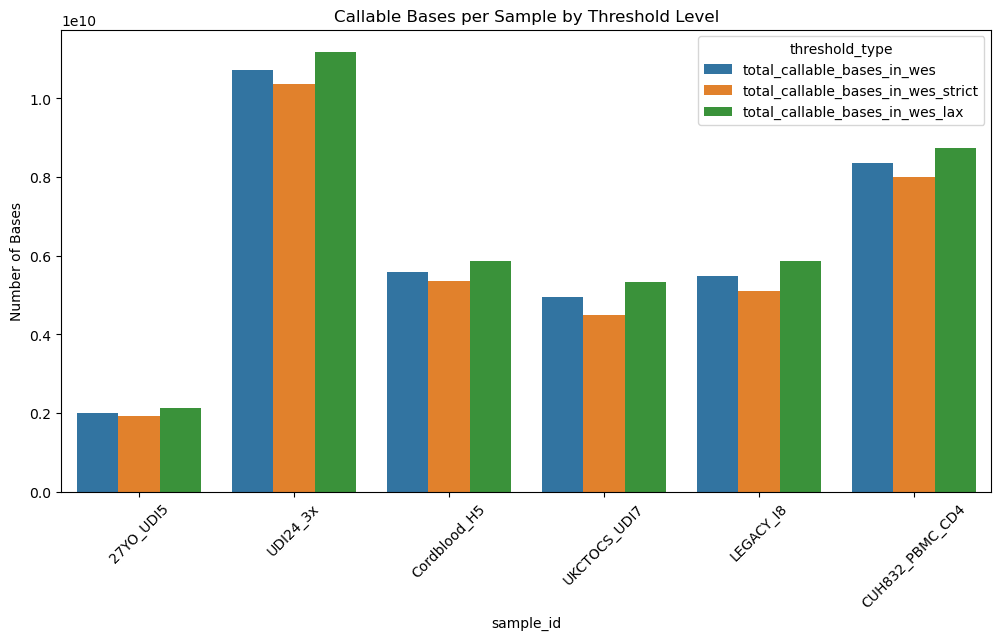

In [2]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='sample_id', y='callable_bases', hue='threshold_type')
plt.title('Callable Bases per Sample by Threshold Level')
plt.ylabel('Number of Bases')
plt.xticks(rotation=45)
plt.show()

In [3]:
# Calculate percentages
df['perc_strict'] = (df['total_callable_bases_in_wes_strict'] / df['total_bases_in_wes']) * 100
df['perc_lax'] = (df['total_callable_bases_in_wes_lax'] / df['total_bases_in_wes']) * 100

# Plotting code similar to the above using the new percentage columns...

/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_97759/992603652.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='Threshold', y='Average Callable Bases', palette='viridis')


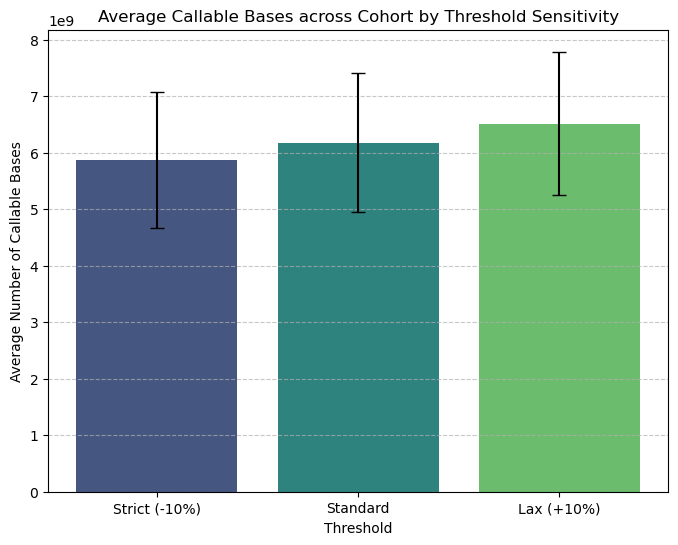

In [4]:
import numpy as np

# 1. Prepare summary statistics
cols = ['total_callable_bases_in_wes_strict', 'total_callable_bases_in_wes', 'total_callable_bases_in_wes_lax']
labels = ['Strict (-10%)', 'Standard', 'Lax (+10%)']

means = df[cols].mean()
sems = df[cols].std() / np.sqrt(len(df))

summary_df = pd.DataFrame({
    'Threshold': labels,
    'Average Callable Bases': means.values,
    'SEM': sems.values
})

# 2. Plotting
plt.figure(figsize=(8, 6))
sns.barplot(data=summary_df, x='Threshold', y='Average Callable Bases', palette='viridis')

# Add error bars manually
plt.errorbar(x=range(len(labels)), y=means.values, yerr=sems.values, fmt='none', c='black', capsize=5)

plt.title('Average Callable Bases across Cohort by Threshold Sensitivity')
plt.ylabel('Average Number of Callable Bases')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

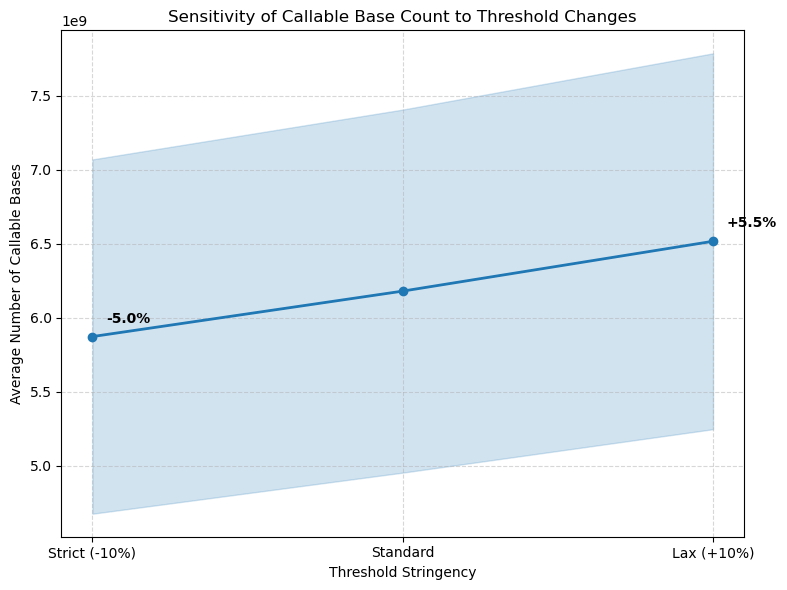

Sensitivity Analysis:
- Strict threshold loses 4.97% of territory
- Lax threshold gains 5.45% of territory


In [5]:
# 1. Calculate percentage changes relative to 'Standard'
standard_val = df['total_callable_bases_in_wes'].mean()
strict_mean = df['total_callable_bases_in_wes_strict'].mean()
lax_mean = df['total_callable_bases_in_wes_lax'].mean()

strict_perc = ((strict_mean - standard_val) / standard_val) * 100
lax_perc = ((lax_mean - standard_val) / standard_val) * 100

# 2. Plotting the slope
plt.figure(figsize=(8, 6))
plt.plot(labels, [strict_mean, standard_val, lax_mean], marker='o', linestyle='-', color='tab:blue', linewidth=2)

# Add shading for the error (SEM)
plt.fill_between(labels, means.values - sems.values, means.values + sems.values, color='tab:blue', alpha=0.2)

# Annotate with the percentage changes
plt.annotate(f'{strict_perc:.1f}%', xy=(labels[0], strict_mean), xytext=(10, 10), textcoords='offset points', fontweight='bold')
plt.annotate(f'{lax_perc:+.1f}%', xy=(labels[2], lax_mean), xytext=(10, 10), textcoords='offset points', fontweight='bold')

plt.title('Sensitivity of Callable Base Count to Threshold Changes')
plt.ylabel('Average Number of Callable Bases')
plt.xlabel('Threshold Stringency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Sensitivity Analysis:\n- Strict threshold loses {abs(strict_perc):.2f}% of territory\n- Lax threshold gains {lax_perc:.2f}% of territory")